# Time Series Analysis: ESN Porto Student Registrations

**Group 26**
- Adriano Machado
- Francisco da Ana
- João Lopes
- Tiago Teixeira

This analysis examines ESN (Erasmus Student Network) card registration patterns from international students in Porto, spanning academic years 2020-2021 through 2025-2026. The data captures the moment students activate their ESN membership, allowing the analysis of international student arrival dynamics.

The dataset comes from ESN Porto's administrative records of ESNcard activations. The ESNcard is a membership card that international students typically purchase when they arrive in Porto, giving them access to various discounts and benefits. The data primarily reflects Erasmus and other exchange students studying at Porto's universities.

In [31]:
import json
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from datetime import datetime, timedelta
from catboost import CatBoostRegressor
from sklearn.model_selection import TimeSeriesSplit
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor

In [32]:
data_dir = Path('data')

with open(data_dir / 'eventupp_students_private.json', 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)

print(f"Loaded data from: {data_dir / 'eventupp_students_private.json'}")
print(f"Total students: {len(df):,}")
print(f"Academic years: {sorted(df['academic_year'].unique())}")

Loaded data from: data/eventupp_students_private.json
Total students: 14,168
Academic years: ['2021_2022', '2022_2023', '2023_2024', '2024_2025', '2025_2026']


In [33]:
# Convert registerDate from milliseconds to datetime
df['registerDate'] = pd.to_datetime(df['registerDate'], unit='ms')

# Set registerDate as index for time series operations
df_ts = df.set_index('registerDate').sort_index()

# Aggregate weekly - count registrations per week
weekly_registrations = df_ts.resample('W').size()

# Create a DataFrame with weekly aggregation
weekly_df = pd.DataFrame({
    'week_ending': weekly_registrations.index,
    'registrations': weekly_registrations.values
})

print(f"\nWeekly aggregation:")
print(f"Total weeks: {len(weekly_df)}")
print(f"Date range: {weekly_df['week_ending'].min()} to {weekly_df['week_ending'].max()}")
print(f"\nFirst 10 weeks:")
weekly_df.head(10)


Weekly aggregation:
Total weeks: 227
Date range: 2021-08-08 00:00:00 to 2025-12-07 00:00:00

First 10 weeks:


,week_ending,registrations
0,2021-08-08,17
1,2021-08-15,22
2,2021-08-22,15
3,2021-08-29,18
4,2021-09-05,196
5,2021-09-12,246
6,2021-09-19,190
7,2021-09-26,145
8,2021-10-03,172
9,2021-10-10,71


In [34]:
# Save to JSON file
output_file = data_dir / 'weekly_students.json'
weekly_df.to_json(output_file, orient='records', date_format='iso', indent=2)
print(f"\nSaved weekly data to: {output_file}")


Saved weekly data to: data/weekly_students.json


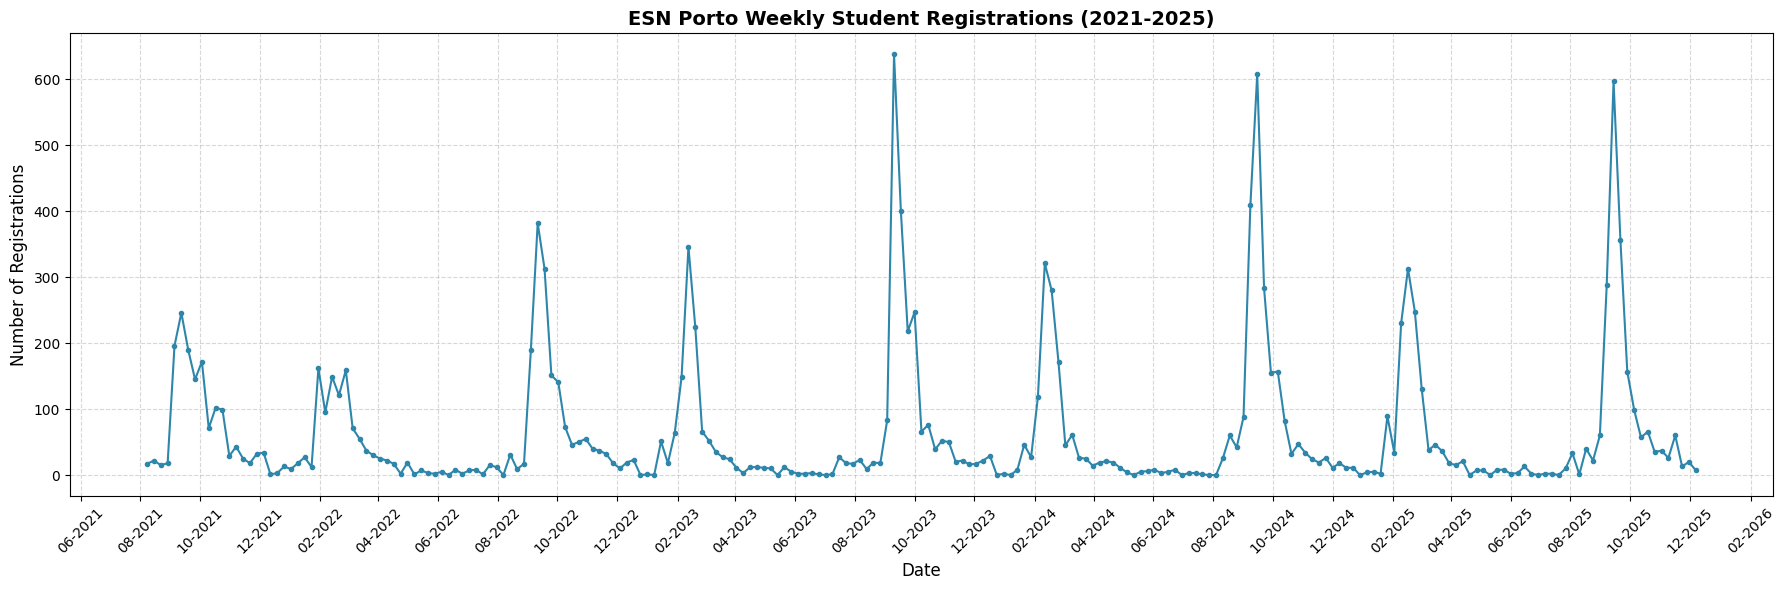

In [35]:
# Plotting the weekly registrations
fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(weekly_df['week_ending'], weekly_df['registrations'], 
        linewidth=1.5, color='#2E86AB', marker='o', markersize=3)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Registrations', fontsize=12)
ax.set_title('ESN Porto Weekly Student Registrations (2021-2025)', fontsize=14, fontweight='bold')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha='center')
ax.grid(True, alpha=0.5, linestyle='--')
plt.tight_layout()

figures_dir = Path('figures')
figures_dir.mkdir(exist_ok=True)

plot_file = figures_dir / 'weekly_registrations.png'
plt.show()

In [36]:
def create_features(df):
    df = df.copy()

    df['month'] = df['week_ending'].dt.month
    df['year'] = df['week_ending'].dt.year
    df['week_of_year'] = df['week_ending'].dt.isocalendar().week.astype(int)

    # Calculate week of month (0-5)
    df['day_of_month'] = df['week_ending'].dt.day
    df['week_of_month'] = ((df['day_of_month'] - 1) // 7)

    # Is welcome month (February=2 or September=9)
    df['is_welcome_month'] = ((df['month'] == 2) | (df['month'] == 9)).astype(int)

    # Semester: 0 for fall (Aug-Jan), 1 for spring (Feb-Jul)
    df['semester'] = ((df['month'] >= 2) & (df['month'] <= 7)).astype(int)

    # Week of semester calculation
    def calculate_week_of_semester(row):
        year = row['year']
        month = row['month']
        week_ending = row['week_ending']

        if month >= 8:  # Fall semester (Aug-Dec)
            semester_start = pd.Timestamp(year=year, month=8, day=1)
        elif month <= 7 and month >= 2:  # Spring semester (Feb-Jul)
            semester_start = pd.Timestamp(year=year, month=2, day=1)
        else:  # January (still fall semester of previous academic year)
            semester_start = pd.Timestamp(year=year-1, month=8, day=1)

        weeks_diff = (week_ending - semester_start).days // 7
        return max(0, weeks_diff)

    df['week_of_semester'] = df.apply(calculate_week_of_semester, axis=1)

    # Lag features
    df['lag1'] = df['registrations'].shift(1)
    df['lag2'] = df['registrations'].shift(2)

    # Rolling average of last 4 weeks
    df['avg_last_4'] = df['registrations'].shift(1).rolling(window=4, min_periods=1).mean()

    # Lag of 1 year ago (52 weeks)
    df['lag_52'] = df['registrations'].shift(52)

    return df

In [37]:
df_features = create_features(weekly_df)
print("Features created.")
df_features.head()

Features created.


,week_ending,registrations,month,year,week_of_year,day_of_month,week_of_month,is_welcome_month,semester,week_of_semester,lag1,lag2,avg_last_4,lag_52
0,2021-08-08,17,8,2021,31,8,1,0,0,1,NaN,NaN,NaN,NaN
1,2021-08-15,22,8,2021,32,15,2,0,0,2,17.0,NaN,17.0,NaN
2,2021-08-22,15,8,2021,33,22,3,0,0,3,22.0,17.0,19.5,NaN
3,2021-08-29,18,8,2021,34,29,4,0,0,4,15.0,22.0,18.0,NaN
4,2021-09-05,196,9,2021,35,5,0,1,0,5,18.0,15.0,18.0,NaN


In [38]:
feature_cols = [
    'week_ending', # useful only for splitting the data, not for modeling
    'is_welcome_month', 
    'semester',  
    'month', 
    'week_of_semester', 
    'lag1', 
    'lag2', 
    'avg_last_4', 
    'lag_52',
    'registrations' # target variable
]

# keep only the features in the list, discard the columns that are not in the list
df_clean = df_features[feature_cols]
# drop NaNs created by lag features
df_clean = df_clean.dropna().copy()
print(f"Clean dataset: {len(df_clean)} weeks")
df_clean.describe()

Clean dataset: 175 weeks


,week_ending,is_welcome_month,semester,month,week_of_semester,lag1,lag2,avg_last_4,lag_52,registrations
count,175,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000
mean,2024-04-07 00:00:00,0.165714,0.445714,6.868571,12.120000,66.177143,66.148571,66.047143,62.160000,66.148571
min,2022-08-07 00:00:00,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,2023-06-07 12:00:00,0.000000,0.000000,4.000000,6.000000,7.500000,7.500000,8.875000,8.000000,7.000000
50%,2024-04-07 00:00:00,0.000000,0.000000,7.000000,12.000000,22.000000,22.000000,21.500000,22.000000,22.000000
75%,2025-02-05 12:00:00,0.000000,1.000000,10.000000,18.000000,58.500000,58.500000,78.500000,60.500000,58.500000
max,2025-12-07 00:00:00,1.000000,1.000000,12.000000,25.000000,638.000000,638.000000,375.750000,638.000000,638.000000
std,NaN,0.372891,0.498471,3.442447,7.409407,114.638901,114.651098,90.535394,102.799647,114.653103


In [39]:
TEST_MONTH = 1
TEST_YEAR = 2025
train_df = df_clean[(df_clean['week_ending'].dt.year < TEST_YEAR) | 
                    ((df_clean['week_ending'].dt.year == TEST_YEAR) & 
                     (df_clean['week_ending'].dt.month < TEST_MONTH))].copy()
test_df = df_clean[(df_clean['week_ending'].dt.year > TEST_YEAR) | 
                   ((df_clean['week_ending'].dt.year == TEST_YEAR) & 
                    (df_clean['week_ending'].dt.month >= TEST_MONTH))].copy()

print(f"\nData Split ")
print(f"Training period: {train_df['week_ending'].min()} to {train_df['week_ending'].max()}")
print(f"Training samples: {len(train_df)} weeks")
print(f"\nTest period: {test_df['week_ending'].min()} to {test_df['week_ending'].max()}")
print(f"Test samples: {len(test_df)} weeks")


Data Split 
Training period: 2022-08-07 00:00:00 to 2024-12-29 00:00:00
Training samples: 126 weeks

Test period: 2025-01-05 00:00:00 to 2025-12-07 00:00:00
Test samples: 49 weeks


In [40]:
def walk_forward_validation(train_df, test_df, model, forecast_horizon=1):
    """
    Perform walk-forward validation within the test period.
    """

    results = []
    fold_metrics = []

    test_weeks = test_df['week_ending'].values
    n_test = len(test_weeks)

    print(f"WALK-FORWARD VALIDATION")
    print(f"Test period: {n_test} weeks")
    print(f"Forecast horizon: {forecast_horizon} week(s)")
    print(f"\n")

    fold = 0
    i = 0

    while i < n_test:
        fold += 1

        # Define the forecast window
        end_idx = min(i + forecast_horizon, n_test)
        forecast_weeks = test_weeks[i:end_idx]

        # Expanding training window
        if i == 0:
            current_train = train_df.copy()
        else:
            historical_test = test_df[test_df['week_ending'] < forecast_weeks[0]]
            current_train = pd.concat([train_df, historical_test], ignore_index=True)

        current_test = test_df[test_df['week_ending'].isin(forecast_weeks)]

        X_train = current_train.drop(columns=['registrations', 'week_ending'])
        y_train = current_train['registrations']
        X_test = current_test.drop(columns=['registrations', 'week_ending'])
        y_test = current_test['registrations']

        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)
        
        # Round predictions to integers
        y_pred = np.round(y_pred).astype(int) 

        # Calculate metrics for this fold (now using the rounded integers)
        mae = np.mean(np.abs(y_test - y_pred))
        rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
        maape = np.mean(np.arctan(np.abs((y_test - y_pred) / (y_test + 1e-10)))) * (180/np.pi)
        me = np.mean(y_test - y_pred) 

        fold_metrics.append({
            'fold': fold,
            'train_size': len(current_train),
            'test_size': len(current_test),
            'forecast_start': pd.Timestamp(forecast_weeks[0]),
            'mae': mae,
            'rmse': rmse,
            'maape': maape,
            'me': me
        })

        for j, week in enumerate(forecast_weeks):
            results.append({
                'week_ending': pd.Timestamp(week),
                'actual': y_test.iloc[j],
                'predicted': y_pred[j],
                'fold': fold,
                'train_size': len(current_train)
            })

        forecast_date = pd.Timestamp(forecast_weeks[0]).strftime('%Y-%m-%d')
        print(f"Fold {fold:2d} | Forecast: {forecast_date} | "
              f"Train: {len(current_train):3d} weeks | "
              f"MAE: {mae:6.2f} | RMSE: {rmse:6.2f} | ME: {me:+6.2f}")

        i = end_idx

    results_df = pd.DataFrame(results)

    return results_df, fold_metrics

In [41]:
models = {
    'XGBoost': XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ),
    
    'CatBoost': CatBoostRegressor(
        iterations=500,
        learning_rate=0.01,
        depth=6,
        l2_leaf_reg=7,
        loss_function='RMSE',
        random_seed=42,
        verbose=False
    ),
    
    'LightGBM': LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    ),
    
    'RandomForest': RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
}

In [42]:
all_results = {}
all_metrics = {}
cur_date = datetime.now().strftime('%Y%m%d_%H%M%S')

for model_name, model in models.items():
    print(f"TRAINING MODEL: {model_name}")
    
    results_df, fold_metrics = walk_forward_validation(
        train_df, test_df, model, forecast_horizon=1
    )
    
    overall_mae = np.mean(np.abs(results_df['actual'] - results_df['predicted']))
    overall_rmse = np.sqrt(np.mean((results_df['actual'] - results_df['predicted']) ** 2))
    overall_maape = np.mean(np.arctan(np.abs((results_df['actual'] - results_df['predicted']) / 
                                              (results_df['actual'] + 1e-10)))) * (180/np.pi)
    overall_me = np.mean(results_df['actual'] - results_df['predicted'])
    
    print(f"RESULTS FOR {model_name}:")
    print(f">> MAE:   {overall_mae:.2f}")
    print(f">> RMSE:  {overall_rmse:.2f}")
    print(f">> MAAPE: {overall_maape:.2f}°")
    print(f">> ME:    {overall_me:+.2f} (bias)\n")
    
    # Store results
    all_results[model_name] = results_df
    all_metrics[model_name] = {
        'mae': overall_mae,
        'rmse': overall_rmse,
        'maape': overall_maape,
        'me': overall_me
    }
    
    # Save individual model results
    results_dir = Path('results') / cur_date / model_name
    results_dir.mkdir(parents=True, exist_ok=True)
    
    results_df.to_csv(results_dir / 'forecast_predictions.csv', index=False)
    train_df[['week_ending', 'registrations']].to_csv(results_dir / 'training_history.csv', index=False)
    
    with open(results_dir / 'metrics_summary.json', 'w') as f:
        json.dump({
            'overall_mae': overall_mae,
            'overall_rmse': overall_rmse,
            'overall_maape': overall_maape,
            'overall_me': overall_me
        }, f, indent=2)
    
    print(f"Saved results to: {results_dir}")

TRAINING MODEL: XGBoost
WALK-FORWARD VALIDATION
Test period: 49 weeks
Forecast horizon: 1 week(s)


Fold  1 | Forecast: 2025-01-05 | Train: 126 weeks | MAE:   4.00 | RMSE:   4.00 | ME:  +4.00
Fold  2 | Forecast: 2025-01-12 | Train: 127 weeks | MAE:  25.00 | RMSE:  25.00 | ME: -25.00
Fold  3 | Forecast: 2025-01-19 | Train: 128 weeks | MAE:  27.00 | RMSE:  27.00 | ME: -27.00
Fold  4 | Forecast: 2025-01-26 | Train: 129 weeks | MAE:  73.00 | RMSE:  73.00 | ME: +73.00
Fold  5 | Forecast: 2025-02-02 | Train: 130 weeks | MAE: 153.00 | RMSE: 153.00 | ME: -153.00
Fold  6 | Forecast: 2025-02-09 | Train: 131 weeks | MAE:  53.00 | RMSE:  53.00 | ME: -53.00
Fold  7 | Forecast: 2025-02-16 | Train: 132 weeks | MAE:   0.00 | RMSE:   0.00 | ME:  +0.00
Fold  8 | Forecast: 2025-02-23 | Train: 133 weeks | MAE: 112.00 | RMSE: 112.00 | ME: +112.00
Fold  9 | Forecast: 2025-03-02 | Train: 134 weeks | MAE:  63.00 | RMSE:  63.00 | ME: +63.00
Fold 10 | Forecast: 2025-03-09 | Train: 135 weeks | MAE:  23.00 | RMSE

In [43]:
# Create comparison summary DataFrame
comparison_df = pd.DataFrame(all_metrics).T
comparison_df = comparison_df.round(2)
comparison_df = comparison_df.sort_values('mae')

print("MODELS (Sorted by MAE)")
print(comparison_df.to_string())

print("\nBEST MODELS BY METRIC:")
print(f"Lowest MAE:    {comparison_df['mae'].idxmin()} ({comparison_df['mae'].min():.2f})")
print(f"Lowest RMSE:   {comparison_df['rmse'].idxmin()} ({comparison_df['rmse'].min():.2f})")
print(f"Lowest MAAPE:  {comparison_df['maape'].idxmin()} ({comparison_df['maape'].min():.2f}°)")
print(f"Closest to 0 ME: {comparison_df['me'].abs().idxmin()} ({comparison_df.loc[comparison_df['me'].abs().idxmin(), 'me']:+.2f})")

# Save comparison summary
comparison_path = Path('results') / cur_date / 'model_comparison.csv'
comparison_df.to_csv(comparison_path)

MODELS (Sorted by MAE)
                mae   rmse  maape    me
RandomForest  23.22  43.12  34.14 -0.41
CatBoost      25.98  44.38  35.70  3.86
XGBoost       29.82  57.91  34.61 -3.00
LightGBM      32.65  59.57  39.84  0.08

BEST MODELS BY METRIC:
Lowest MAE:    RandomForest (23.22)
Lowest RMSE:   RandomForest (43.12)
Lowest MAAPE:  RandomForest (34.14°)
Closest to 0 ME: LightGBM (+0.08)


Saved metrics comparison plot to: results/20251210_163859/model_comparison_metrics.png


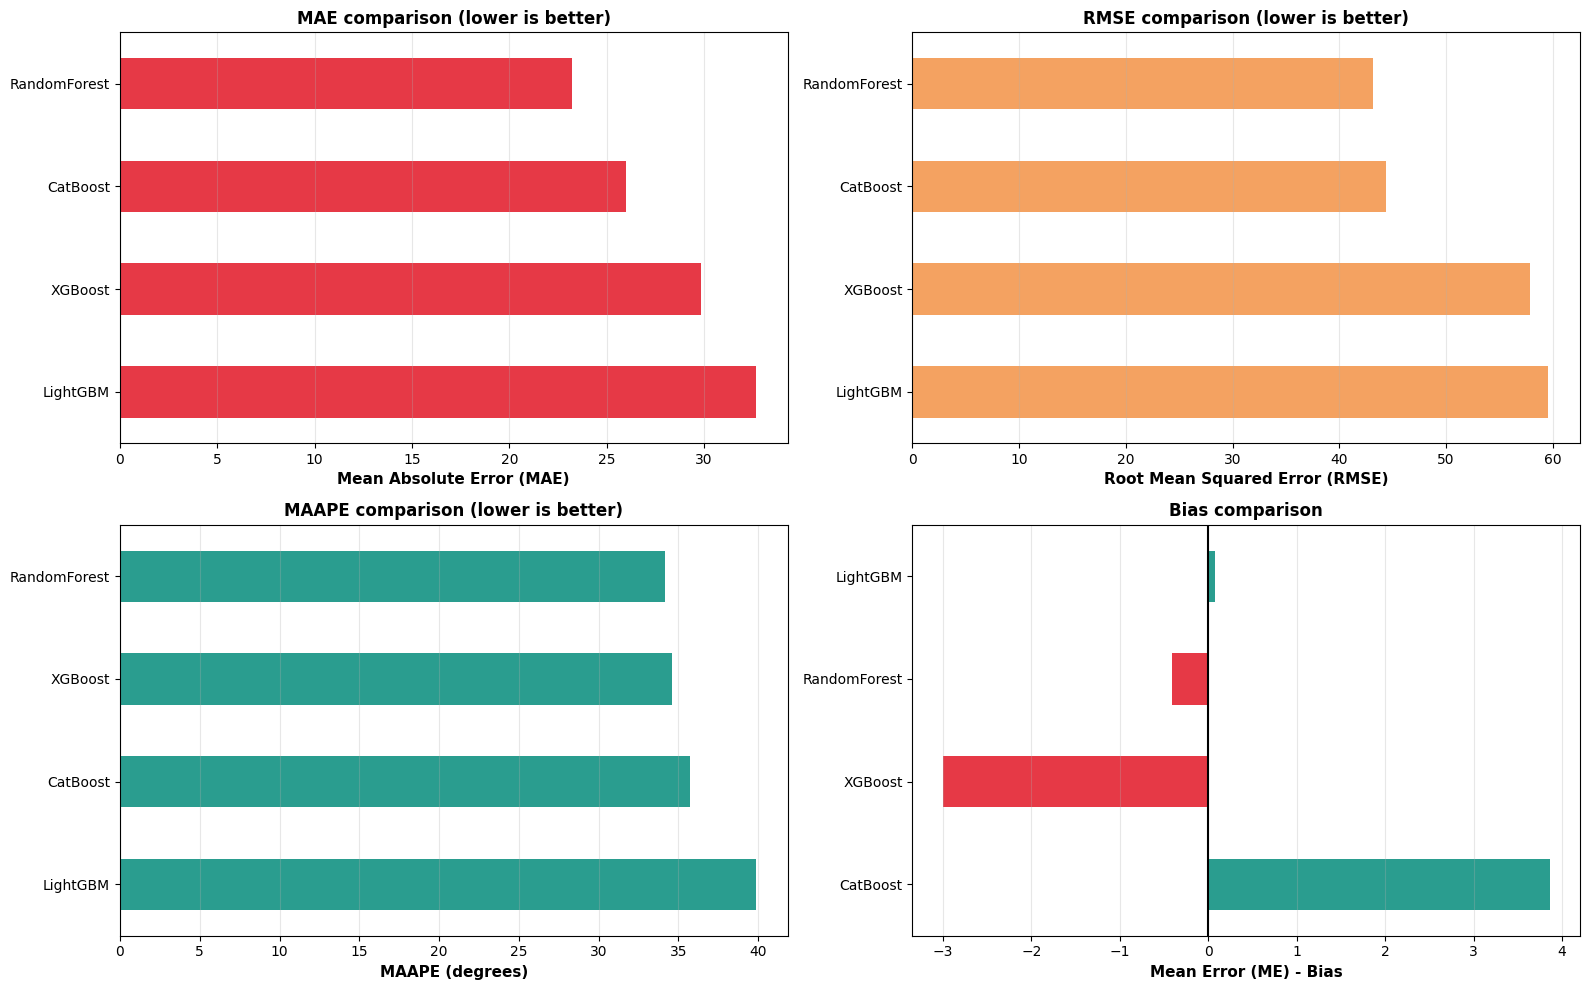

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# MAE Comparison 
ax1 = axes[0, 0]
mae_sorted = comparison_df.sort_values('mae', ascending=False)
mae_sorted['mae'].plot(kind='barh', ax=ax1, color='#E63946')
ax1.set_xlabel('Mean Absolute Error (MAE)', fontsize=11, fontweight='bold')
ax1.set_title('MAE comparison (lower is better)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')


# RMSE Comparison 
ax2 = axes[0, 1]
rmse_sorted = comparison_df.sort_values('rmse', ascending=False)
rmse_sorted['rmse'].plot(kind='barh', ax=ax2, color='#F4A261')
ax2.set_xlabel('Root Mean Squared Error (RMSE)', fontsize=11, fontweight='bold')
ax2.set_title('RMSE comparison (lower is better)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# MAAPE Comparison 
ax3 = axes[1, 0]
maape_sorted = comparison_df.sort_values('maape', ascending=False)
maape_sorted['maape'].plot(kind='barh', ax=ax3, color='#2A9D8F')
ax3.set_xlabel('MAAPE (degrees)', fontsize=11, fontweight='bold')
ax3.set_title('MAAPE comparison (lower is better)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

# ME (Bias) Comparison
ax4 = axes[1, 1]
me_sorted = comparison_df.iloc[comparison_df['me'].abs().argsort()[::-1]]
me_colors = ['#E63946' if x < 0 else '#2A9D8F' for x in me_sorted['me']]
me_sorted['me'].plot(kind='barh', ax=ax4, color=me_colors)
ax4.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
ax4.set_xlabel('Mean Error (ME) - Bias', fontsize=11, fontweight='bold')
ax4.set_title('Bias comparison', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
save_path = Path('results') / cur_date / 'model_comparison_metrics.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved metrics comparison plot to: {save_path}")
plt.show()

Saved overlay comparison plot to: results/20251210_163859/model_comparison_overlay.png


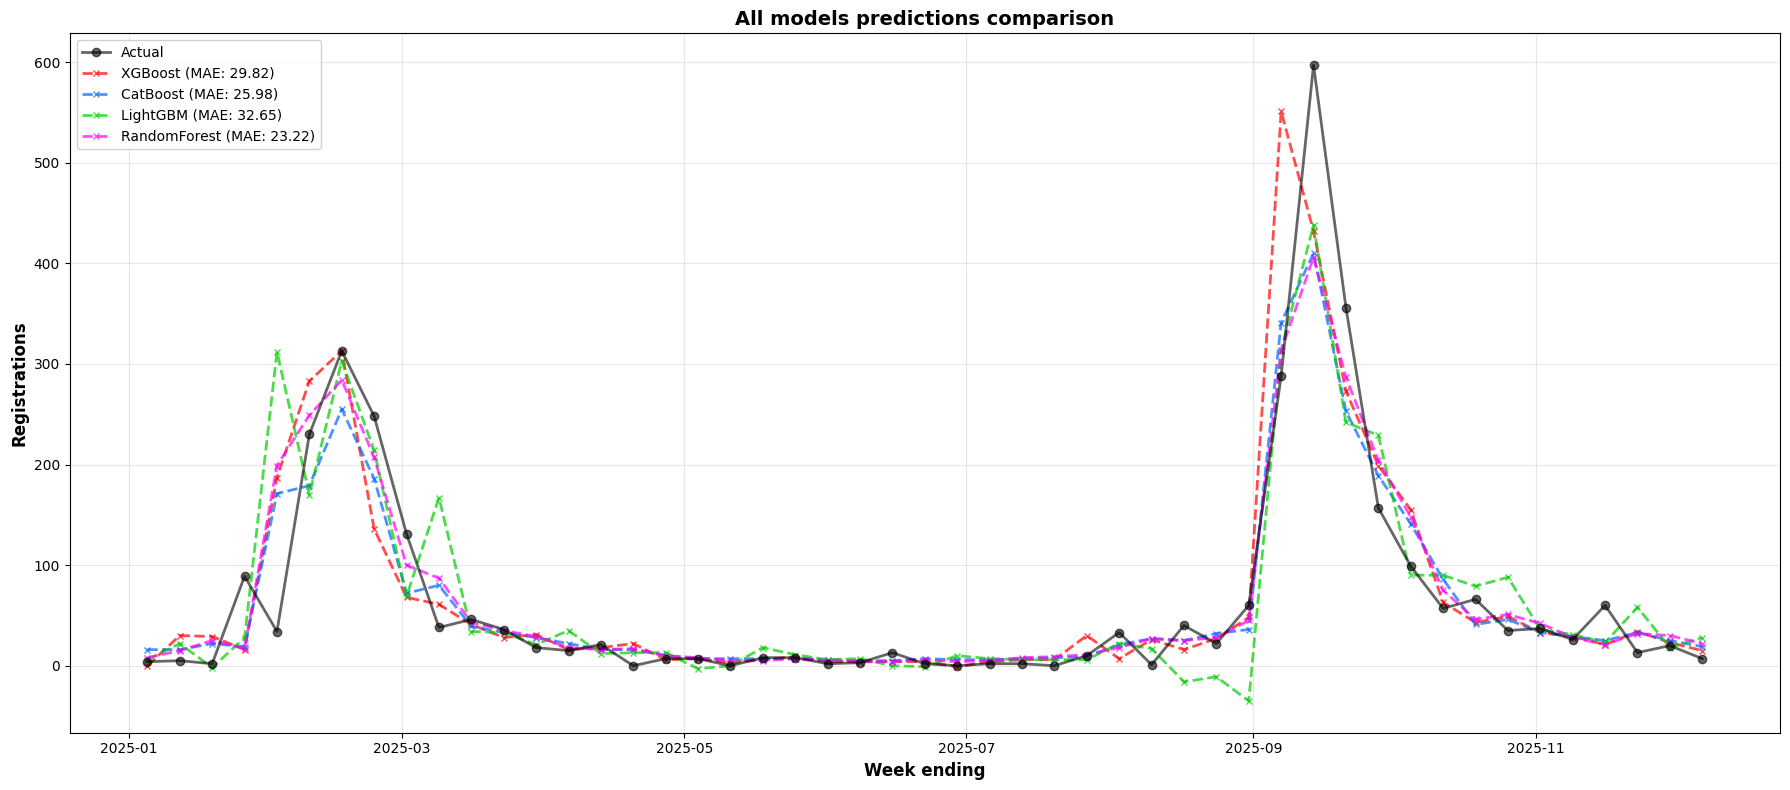

In [45]:
fig, ax = plt.subplots(figsize=(18, 8))

colors = ['#FF0000', '#0066FF', '#00CC00', '#FF00FF', '#FF8800']

first_model = list(all_results.keys())[0]
ax.plot(all_results[first_model]['week_ending'], 
        all_results[first_model]['actual'], 
        label='Actual', color='black', marker='o', linewidth=2, markersize=6, zorder=10, alpha=0.6)

for idx, (model_name, results_df) in enumerate(all_results.items()):
    metrics = all_metrics[model_name]
    ax.plot(results_df['week_ending'], results_df['predicted'], 
            label=f'{model_name} (MAE: {metrics["mae"]:.2f})', 
            color=colors[idx], linestyle='--', marker='x', linewidth=2, markersize=4, alpha=0.7)

ax.set_xlabel('Week ending', fontsize=12, fontweight='bold')
ax.set_ylabel('Registrations', fontsize=12, fontweight='bold')
ax.set_title('All models predictions comparison', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()

save_path = Path('results') / cur_date / 'model_comparison_overlay.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved overlay comparison plot to: {save_path}")
plt.show()